<a href="https://colab.research.google.com/github/tarannump096-cpu/NLP/blob/main/Student_Performance_Dataset_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

# Load Dataset
df = pd.read_csv("/content/student-por.csv")

In [5]:
# Calculate and display summary statistics for numerical columns
display(df.describe())

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


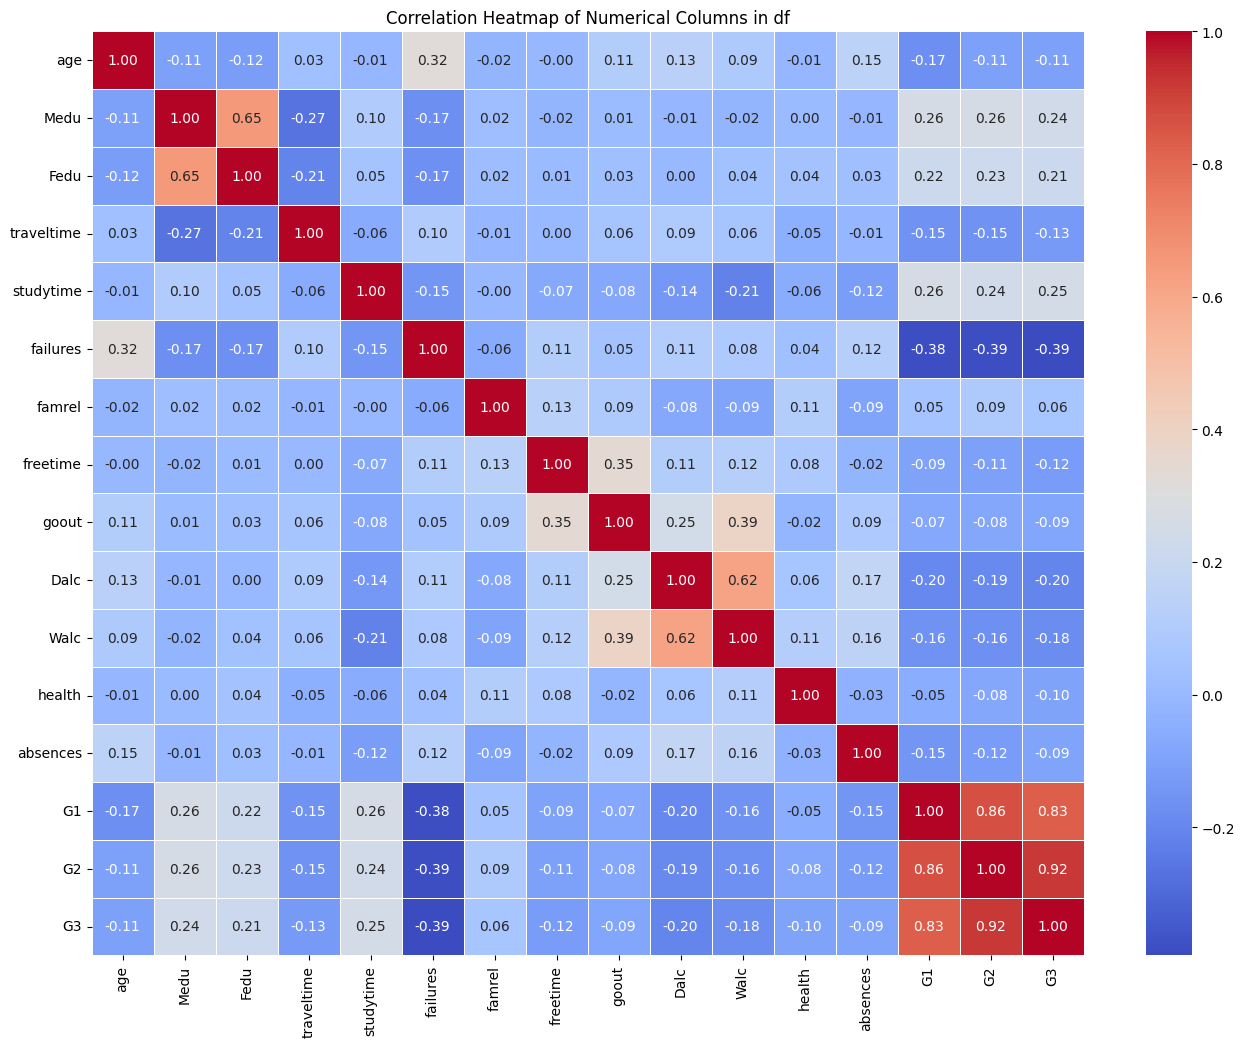

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation heatmap
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Columns in df')
plt.show()

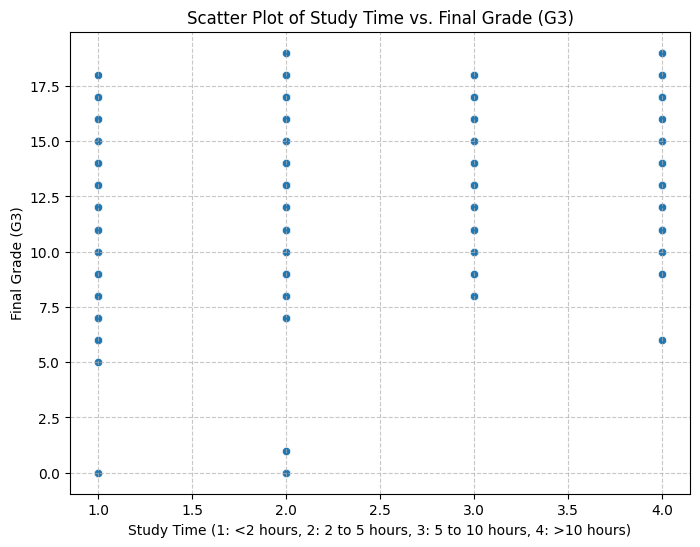

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='studytime', y='G3', data=df)
plt.title('Scatter Plot of Study Time vs. Final Grade (G3)')
plt.xlabel('Study Time (1: <2 hours, 2: 2 to 5 hours, 3: 5 to 10 hours, 4: >10 hours)')
plt.ylabel('Final Grade (G3)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

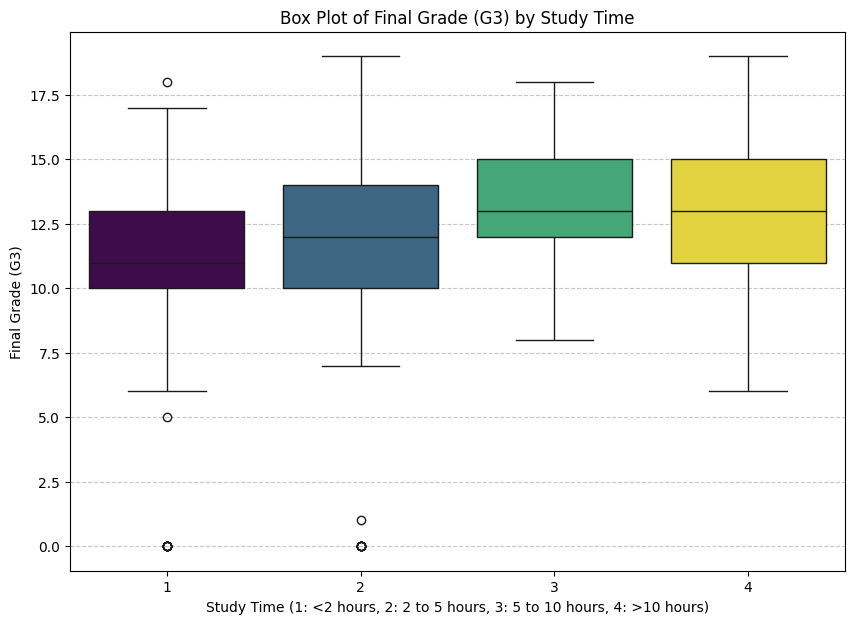

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.boxplot(x='studytime', y='G3', data=df, palette='viridis', hue='studytime', legend=False)
plt.title('Box Plot of Final Grade (G3) by Study Time')
plt.xlabel('Study Time (1: <2 hours, 2: 2 to 5 hours, 3: 5 to 10 hours, 4: >10 hours)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

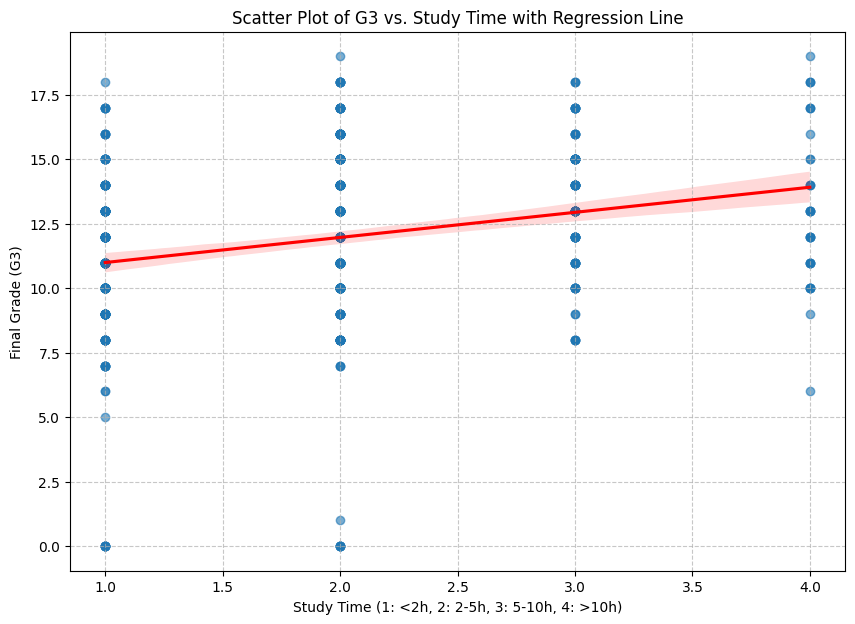

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.regplot(x='studytime', y='G3', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Scatter Plot of G3 vs. Study Time with Regression Line')
plt.xlabel('Study Time (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)')
plt.ylabel('Final Grade (G3)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [11]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


### Regression Model to Predict G3

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df[['studytime', 'failures', 'G1', 'G2']]
y = df['G3']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 0.74
Mean Squared Error (MSE): 1.34
Root Mean Squared Error (RMSE): 1.16
R-squared (R2): 0.86


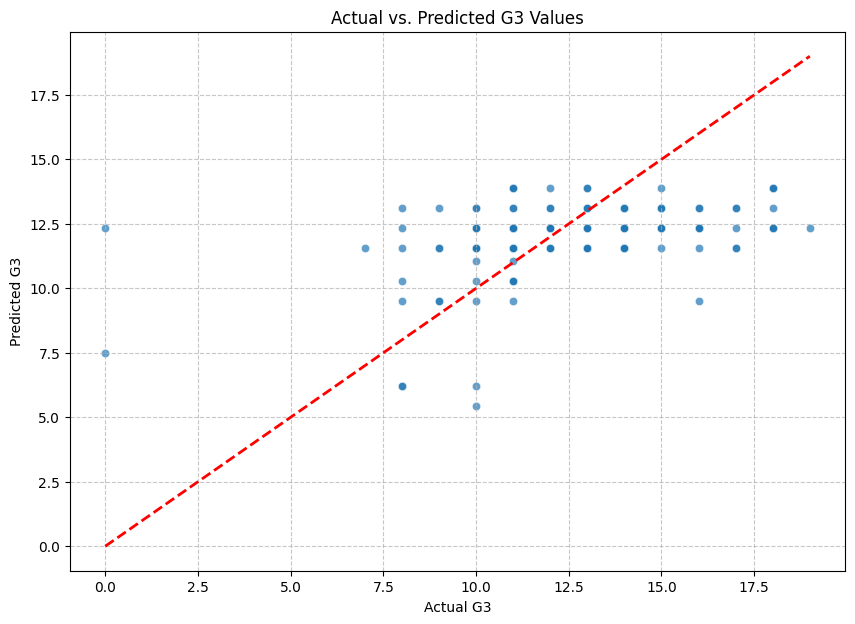

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.title('Actual vs. Predicted G3 Values')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

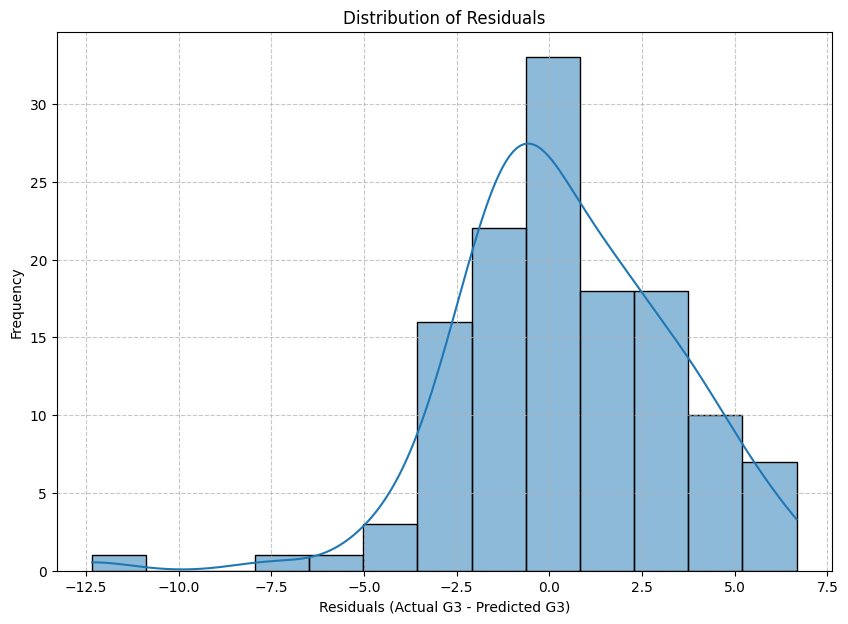

In [16]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 7))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual G3 - Predicted G3)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

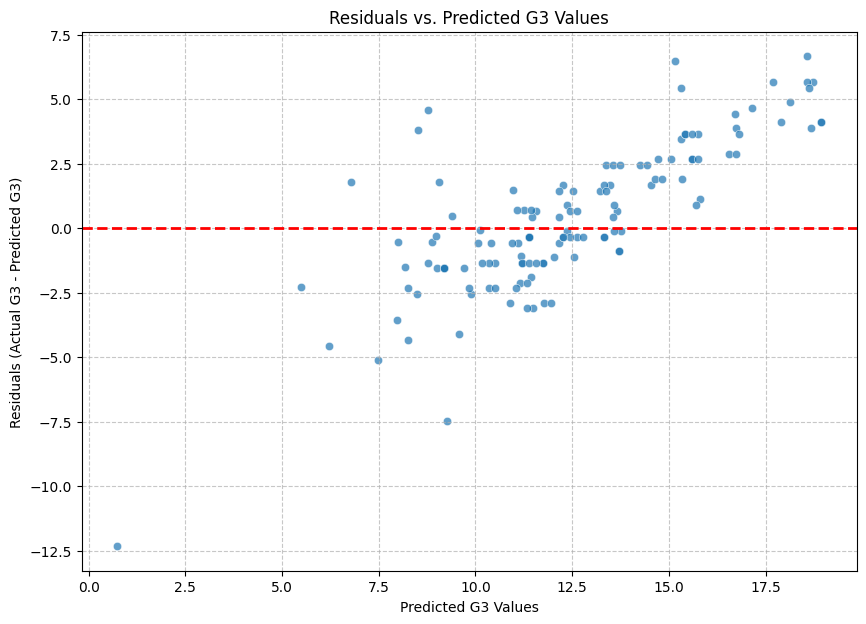

In [21]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Add a horizontal line at y=0
plt.title('Residuals vs. Predicted G3 Values')
plt.xlabel('Predicted G3 Values')
plt.ylabel('Residuals (Actual G3 - Predicted G3)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [14]:
# Display correlations of 'studytime' and 'failures' with 'G3'
print("Correlation of 'studytime' with 'G3':", correlation_matrix.loc['G3', 'studytime'])
print("Correlation of 'failures' with 'G3':", correlation_matrix.loc['G3', 'failures'])

Correlation of 'studytime' with 'G3': 0.24978868999886306
Correlation of 'failures' with 'G3': -0.39331554804199254


In [15]:
# Display the coefficients of 'studytime' and 'failures' from the trained model
feature_names = X.columns
coefficients = model.coef_

for feature, coef in zip(feature_names, coefficients):
    print(f"Coefficient for '{feature}': {coef:.2f}")

Coefficient for 'studytime': 0.77
Coefficient for 'failures': -2.04


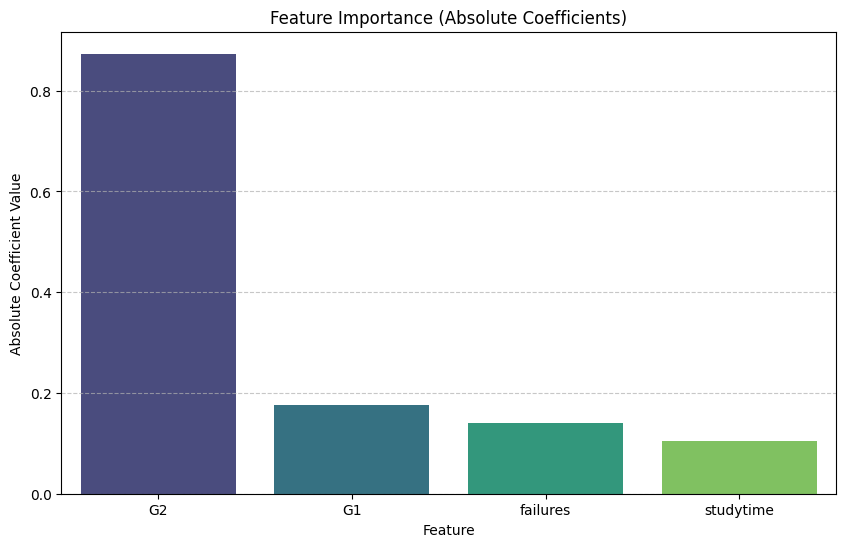

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for coefficients using all features from X
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

# Use absolute values for importance visualization
feature_importance['Absolute_Coefficient'] = feature_importance['Coefficient'].abs()

# Sort by importance for better visualization
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Absolute_Coefficient', data=feature_importance, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance (Absolute Coefficients)')
plt.xlabel('Feature')
plt.ylabel('Absolute Coefficient Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based on these values, we can compare their impact. A larger absolute correlation coefficient indicates a stronger linear relationship. For the regression coefficients, a larger absolute value suggests a greater change in G3 for a one-unit change in the feature, assuming other features are held constant.

### Impact of Outliers on Regression Coefficients

Outliers, especially influential outliers, can significantly distort the regression line and, consequently, the regression coefficients. Here's why:

1.  **Pulling the Regression Line:** Outliers are data points that lie far away from the other observations. In a least squares regression, the model tries to minimize the sum of squared residuals. A single outlier with a large residual will contribute disproportionately to this sum. To minimize this large squared error, the regression line will be 'pulled' towards the outlier.

2.  **Biased Coefficients:** This pulling effect can lead to biased or misleading regression coefficients. The slope and intercept of the regression line might change substantially to accommodate the outlier, making the coefficients less representative of the true relationship between the variables for the majority of the data.

3.  **Increased Standard Errors:** Outliers can also increase the standard errors of the coefficients, making them appear less statistically significant. This is because the overall variability around the regression line increases.

4.  **Reduced R-squared:** While not always the case, outliers can sometimes inflate or deflate the R-squared value, giving a false impression of the model's explanatory power.

**In summary, highly influential outliers can lead to a regression model that performs poorly on new data because it has been unduly influenced by a few extreme observations rather than reflecting the general trend in the data.** Therefore, identifying and understanding outliers is a crucial step in regression analysis, often leading to decisions about whether to remove them, transform the data, or use more robust regression methods.